In [7]:
import numpy as np
import scipy
import scipy.special as sp
import matplotlib.pyplot as plt
import h5py
from localized_2d import WfnParams, Wavefunction, HamiltParams, Hamilt

In [106]:
def get_loc_matrix_for_coupling(dir,Mx,My,tx,ty,B,V_0):
    file_path = dir+'data_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'
    
    with h5py.File(file_path, 'r') as f:
        phi_data = f["wfn"][...]
        Mx = f["Mx"][...]
        My = f["My"][...]
        n = f["n"][...]
        B = f["B"][...]
        tx = f["tx"][...]
        ty = f["ty"][...]
        V_0 = f["V0"][...]
        e_tun = f["e_tun"][...]
        v_tun = f["v_tun"][...]
        
    wfnpar = WfnParams(Mx, My, n)
    Mx, My, n, x, k2 = wfnpar.read()

    wfn = Wavefunction(wfnpar, array=phi_data)

    hamiltpar = HamiltParams(B, tx, ty, V_0)

    H = Hamilt(wfnpar, hamiltpar)
    energy_tot, energy_rot, energy_ele, energy_int = H.calculate_energy(wfn)
    #Tx, Ty = H.calc_Tx_Ty(wfn)
    H, B = H.calculate_tunnelings(wfn)
    
    return H, B

def get_pbc_index(M):
    kmu = np.arange(Mx)
    kmu[kmu > M/2] = -(kmu[kmu > M/2]%(M/2))[::-1]
    return kmu

def get_ope_fourier(Mx,My,Op):
    return np.einsum('ij->', Op)
    
def get_first_deriv_ope_fourier(Mx,My,Op):
    kx = get_pbc_index(Mx)
    ky = get_pbc_index(My)

    dOp_dkx = np.einsum('ij,i->', Op, 1j*kx)
    dOp_dky = np.einsum('ij,j->', Op, 1j*ky)

    return dOp_dkx, dOp_dky
    
def get_sec_deriv_ope_fourier(Mx,My,Op):
    kx = get_pbc_index(Mx)
    ky = get_pbc_index(My)
    
    d2Op_dkx2 = np.einsum('ij,i->', Op, -kx**2)
    d2Op_dky2 = np.einsum('ij,j->', Op, -ky**2)

    return d2Op_dkx2, d2Op_dky2

def get_eff_mass(E_He,dHe_dk,d2He_dk2,S_psi,dS_dk,d2S_dk2):
    term1 = (1/S_psi)*d2He_dk2
    term2 = -2*(dHe_dk/S_psi**2)*dS_dk
    term3 = -(E_He/S_psi**2)*d2S_dk2
    term4 = 2*(E_He/S_psi**3)*dS_dk**2

    #print('\n',term1,term2,term3,term4,'\n')
    d2E_dk2 = term1+term2+term3+term4
    m = 1/d2E_dk2
    return m

def get_eff_mass_arr(tx_arr,V_0_arr,Mx,My,B):
    mx = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    my = np.zeros((len(ty_arr),len(V_0_arr)), dtype=complex)
    dir = 'data_localized/'
    for j in range(len(tx_arr)):
        for i in range(len(V_0_arr)):
            tx = tx_arr[j]
            ty = ty_arr[j]
        
            H, S = get_loc_matrix_for_coupling(dir=dir,Mx=Mx,My=My,tx=tx,ty=ty,B=B,V_0=V_0_arr[i])

            E_H = get_ope_fourier(Mx,My,H)
            dH_dkx, dH_dky = get_first_deriv_ope_fourier(Mx,My,H)
            d2H_dkx2, d2H_dky2 = get_sec_deriv_ope_fourier(Mx,My,H)
    
            S_psi = get_ope_fourier(Mx,My,S)
            dS_dkx, dS_dky = get_first_deriv_ope_fourier(Mx,My,S)
            d2S_dkx2, d2S_dky2 = get_sec_deriv_ope_fourier(Mx,My,S)

            mx[j,i] = get_eff_mass(E_H,dH_dkx,d2H_dkx2,S_psi,dS_dkx,d2S_dkx2)
            my[j,i] = get_eff_mass(E_H,dH_dky,d2H_dky2,S_psi,dS_dky,d2S_dky2) #(Mx*My)/np.sum(my2Hem)

            print('V_0, m_x, m_y =', V_0_arr[i], E_H, mx[j,i], my[j,i])

    return mx, my
    
'''
Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr = np.array([0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6,2.8,3.0])

Mx = 20
My = 20
tx_arr = np.array([0.5,0.6,0.7,0.8,0.9,1.0])
ty_arr = np.array([0.5,0.4,0.3,0.2,0.1,0.0])
B = 1e-2

mx, my = get_eff_mass_arr(tx_arr,V_0_arr,Mx,My,B)

V_0, m_x, m_y = 0.4 (-2.2870251891099524-1.0570282323524497e-19j) (977.3020796790246-4.1845670483118714e-15j) (977.3020796790196+1.1883712378772474e-14j)
V_0, m_x, m_y = 0.6 (-2.7928357105989607+9.267253006707649e-19j) (6988.678648243406+2.850671716048691e-14j) (6988.67864824536-7.572042064607022e-14j)
V_0, m_x, m_y = 0.8 (-3.415218100583223-7.211727299874396e-19j) (27649.42991136093+1.1013411897285953e-13j) (27649.429911370193-1.5670727745521386e-13j)
V_0, m_x, m_y = 1.0 (-4.09155701391214-8.390573359722417e-19j) (65639.32056335126+2.1588140996060893e-13j) (65639.3205630757-3.8291073919120444e-13j)
V_0, m_x, m_y = 1.2 (-4.799012381553753+7.247959629284337e-19j) (108749.76821798005-5.185897467556423e-13j) (108749.76821796433-9.517368494590848e-15j)
V_0, m_x, m_y = 1.4 (-5.526201947289707+1.1990984505559464e-18j) (143313.31529124206-2.9168011782528987e-13j) (143313.31529127003+7.6980069161595e-15j)
V_0, m_x, m_y = 1.6 (-6.266711263443447-6.948535155327581e-19j) (163482.2619899814-2.9819

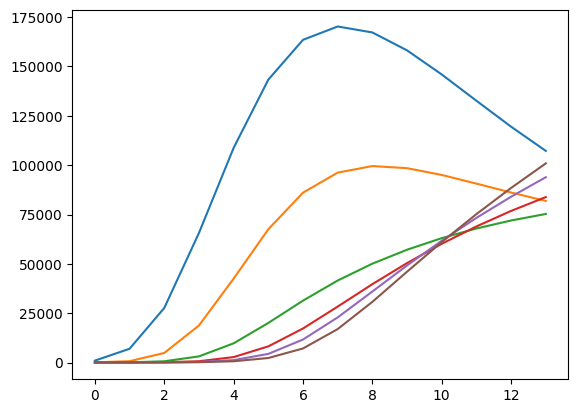

In [115]:
plt.plot(mx.T.real)
#plt.plot(my.T.real)

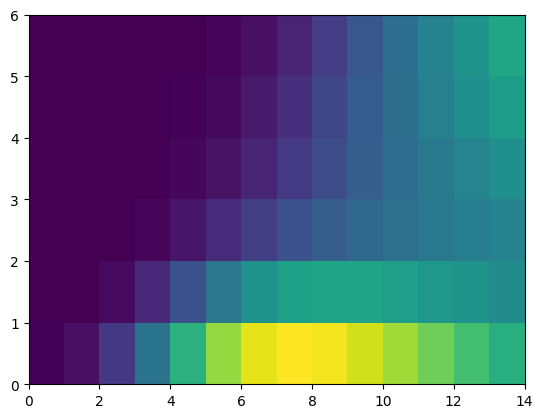

In [109]:
plt.pcolormesh(mx.real)

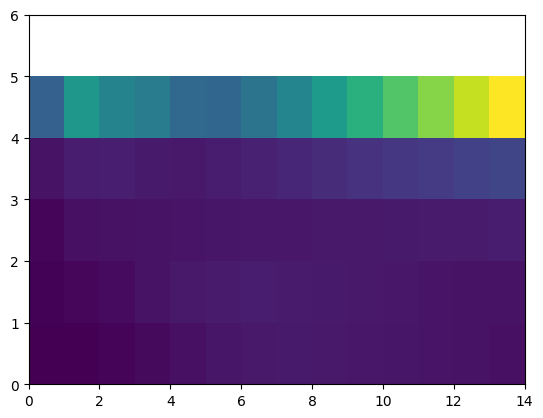

In [110]:
plt.pcolormesh(my.real)